# 01 · LCA en EPH 2017-2018

Entrenamos un modelo de Latent Class Analysis sobre los ocupados de EPH 2017-2018 (ventana coincidente con la ENGH 2017/18) y aplicamos las clases resultantes a todo el panel 2017-2025.

**Variables indicadoras (6, todas categóricas):**
- `SEXO` (Varón/Mujer)
- `EDAD_GRP` (5 buckets)
- `NIVEL_ED_3` (Hasta_primario / Secundario / Superior)
- `CAT_OCUP` (Patrón / Cuenta propia / Obrero o empleado / Trab. familiar)
- `FORMAL` (Formal / Informal / NoAplica)
- `REGION` (6 regiones del INDEC)

**Selección de k:** se ajusta para k=2..7 sobre una muestra de 30k para velocidad y se elige por BIC + interpretabilidad.

**Salidas:**
- `data/lca_bic_curve.csv`
- `data/lca_model.pkl` (modelo + encoders)
- `data/eph_with_lca.parquet` (todos los ocupados 2017+ con clase asignada)
- `figures/01_bic_curve.png`

In [1]:
import pandas as pd
import numpy as np
import pickle, warnings, time
warnings.filterwarnings("ignore")
from stepmix import StepMix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

eph = pd.read_parquet("data/eph_ocupados_2017plus.parquet")
print("EPH ocupados 2017+:", eph.shape)

mask_train = eph["ANO4"].isin([2017, 2018])
eph_train = eph[mask_train].copy()
print("EPH 2017-2018 (training del LCA):", eph_train.shape)

# Submuestreo para velocidad — 30k es suficiente para LCA con 6 indicadores
rng = np.random.default_rng(42)
idx = rng.choice(len(eph_train), size=min(30_000, len(eph_train)), replace=False)
eph_lca = eph_train.iloc[idx].reset_index(drop=True)

EPH ocupados 2017+: (752087, 14)
EPH 2017-2018 (training del LCA): (191131, 14)


## Encoding categórico

In [2]:
LCA_VARS = ["SEXO","EDAD_GRP","NIVEL_ED_3","CAT_OCUP","FORMAL","REGION"]

encoders = {}
X = pd.DataFrame()
for v in LCA_VARS:
    le = LabelEncoder()
    X[v] = le.fit_transform(eph_lca[v].astype(str))
    encoders[v] = le
    print(f"  {v}: {dict(zip(le.classes_, range(len(le.classes_))))}")

  SEXO: {'Mujer': 0, 'Varon': 1}
  EDAD_GRP: {'25-34': 0, '35-49': 1, '50-64': 2, '65+': 3, '<25': 4}
  NIVEL_ED_3: {'Hasta_primario': 0, 'Secundario': 1, 'Superior': 2}
  CAT_OCUP: {'Cuenta Propia': 0, 'Obrero o empleado': 1, 'Patron': 2, 'Trabajador familiar sin remuneracion': 3}
  FORMAL: {'Formal': 0, 'Informal': 1, 'NoAplica': 2}
  REGION: {'Cuyo': 0, 'Gran Buenos Aires': 1, 'NEA': 2, 'NOA': 3, 'Pampeana': 4, 'Patagonia': 5}


## Curva BIC

k=2  BIC=360348.6  (0.3s)
k=3  BIC=357064.6  (2.1s)
k=4  BIC=356025.0  (2.2s)
k=5  BIC=355218.4  (2.2s)
k=6  BIC=355265.7  (2.2s)
k=7  BIC=354875.7  (2.4s)


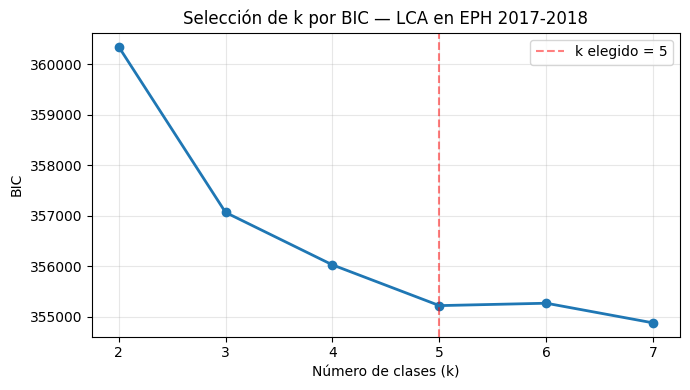

In [3]:
results = []
for k in range(2, 8):
    t0 = time.time()
    m = StepMix(n_components=k, measurement="categorical",
                n_init=2, max_iter=150, random_state=42, progress_bar=0)
    m.fit(X)
    results.append({"k":k, "BIC":m.bic(X), "AIC":m.aic(X), "time_s":time.time()-t0})
    print(f"k={k}  BIC={m.bic(X):.1f}  ({results[-1]['time_s']:.1f}s)")

bic_curve = pd.DataFrame(results)
bic_curve.to_csv("data/lca_bic_curve.csv", index=False)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(bic_curve["k"], bic_curve["BIC"], "o-", lw=2)
ax.axvline(5, ls="--", color="red", alpha=0.5, label="k elegido = 5")
ax.set_xlabel("Número de clases (k)")
ax.set_ylabel("BIC")
ax.set_title("Selección de k por BIC — LCA en EPH 2017-2018")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("figures/01_bic_curve.png", dpi=120)
plt.show()

## Ajuste final con k=5 y caracterización de las clases

Se elige **k=5** como punto de equilibrio entre ajuste (BIC) e interpretabilidad. La curva BIC muestra una caída clara hasta k=5 y luego se aplana / oscila — señal de que clases adicionales no aportan estructura sustantiva.

In [4]:
K = 5
m = StepMix(n_components=K, measurement="categorical",
            n_init=10, max_iter=300, random_state=42, progress_bar=0)
m.fit(X)
print(f"k={K}  BIC={m.bic(X):.1f}  ll/n={m.score(X):.4f}")

post = m.predict_proba(X)
eph_lca["LCA_class"] = post.argmax(axis=1)
print("\nTamaño de clases:")
print(eph_lca["LCA_class"].value_counts().sort_index())

k=5  BIC=355216.7  ll/n=-5.9050

Tamaño de clases:
LCA_class
0    4748
1    7691
2    9018
3    5248
4    3295
Name: count, dtype: int64


In [6]:
# Perfil de cada clase: moda de cada variable
print("=== PERFILES ===\n")
for c in sorted(eph_lca["LCA_class"].unique()):
    sub = eph_lca[eph_lca["LCA_class"]==c]
    print(f"Clase {c}  (n={len(sub)}, {len(sub)/len(eph_lca)*100:.1f}%)")
    for v in LCA_VARS:
        top = sub[v].value_counts(normalize=True)
        print(f"  {v:12s}: " + ", ".join(f"{k}={v*100:.0f}%" for k,v in top.items()))
    print()

=== PERFILES ===

Clase 0  (n=4748, 15.8%)
  SEXO        : Varon=93%, Mujer=7%
  EDAD_GRP    : 35-49=35%, 25-34=34%, 50-64=17%, <25=14%, 65+=0%
  NIVEL_ED_3  : Secundario=94%, Hasta_primario=6%
  CAT_OCUP    : Obrero o empleado=100%
  FORMAL      : Formal=100%
  REGION      : Pampeana=27%, Patagonia=21%, Gran Buenos Aires=19%, NOA=17%, Cuyo=8%, NEA=8%

Clase 1  (n=7691, 25.6%)
  SEXO        : Varon=64%, Mujer=36%
  EDAD_GRP    : 35-49=35%, 50-64=30%, 25-34=18%, 65+=8%, <25=8%
  NIVEL_ED_3  : Secundario=45%, Superior=30%, Hasta_primario=25%
  CAT_OCUP    : Cuenta Propia=81%, Patron=16%, Trabajador familiar sin remuneracion=2%
  FORMAL      : NoAplica=100%
  REGION      : Pampeana=32%, NOA=22%, Gran Buenos Aires=18%, Cuyo=10%, NEA=9%, Patagonia=8%

Clase 2  (n=9018, 30.1%)
  SEXO        : Mujer=67%, Varon=33%
  EDAD_GRP    : 35-49=45%, 50-64=25%, 25-34=25%, <25=4%, 65+=1%
  NIVEL_ED_3  : Superior=78%, Secundario=22%
  CAT_OCUP    : Obrero o empleado=100%
  FORMAL      : Formal=95%, Infor

### Etiquetas interpretables

A partir de los perfiles anteriores, cada clase recibe un nombre. **Estos nombres no salen de los datos: son la lectura humana del perfil dominante.**

| Clase | Etiqueta tentativa |
|---|---|
| 0 | Obreros formales con secundario |
| 1 | Asalariados informales jóvenes |
| 2 | Trabajadores mayores con primario |
| 3 | Profesionales asalariadas |
| 4 | Cuentapropistas y patrones |

## Aplicar el modelo a todo EPH 2017-2025

In [7]:
X_full = pd.DataFrame()
for v in LCA_VARS:
    le = encoders[v]
    s = eph[v].astype(str)
    known = set(le.classes_)
    s = s.where(s.isin(known), list(known)[0])
    X_full[v] = le.transform(s)

post_full = m.predict_proba(X_full)
eph["LCA_class"] = post_full.argmax(axis=1)
for c in range(K):
    eph[f"LCA_p{c}"] = post_full[:, c]

eph.to_parquet("data/eph_with_lca.parquet", index=False)
print(f"\nGuardado eph_with_lca.parquet con {len(eph)} filas y clase asignada.")
print("\nDistribución de clases (panel completo 2017+):")
print(eph["LCA_class"].value_counts(normalize=True).sort_index().round(3))

with open("data/lca_model.pkl","wb") as f:
    pickle.dump({"model":m, "encoders":encoders, "vars":LCA_VARS, "k":K}, f)


Guardado eph_with_lca.parquet con 752087 filas y clase asignada.

Distribución de clases (panel completo 2017+):
LCA_class
0    0.148
1    0.263
2    0.305
3    0.184
4    0.100
Name: proportion, dtype: float64
